# 01 — Stage B Retraining

**FusionCore v2 — Phase Ph-v2.0**

Stage B retrains PiNet from the deterministic Ph-v1.2 init under four
hyperparameter changes designed to address the v1 Critical-recall failure
(lessons v1.P13 and v1.P14):

| Change | v1 Stage A | v2 Stage B | Source lesson |
|---|---|---|---|
| Learning rate | 1e-3 | **3e-4** | v1.P13 — Stage A converged in 3 epochs and overfit thereafter |
| TCN dropout | 0.15 | **0.25** | v1.P13 — widen the val plateau before train/val divergence |
| Train sampler | Stratified 45/27.5/27.5 | **Natural distribution + class-weighted CE only** | v1.P14 — stratified bias mis-calibrated against truncated NASA test |
| NASA loss scale | 1× | **1/50** | v1.P13 — re-balance against CE so the classification head can learn |

All other architecture and data parameters remain frozen at v1 values
(W = 30, embedding 128, etc.).

### Training schedule
- Optimiser: AdamW (weight decay 1e-4)
- LR schedule: warmup over first epoch, cosine to 0 over remaining
- Max epochs: 120
- Early stop: patience 25 on Internal Val NASA score
- Batch size: 64
- Gradient clip: max norm 5.0
- Best-checkpoint criterion: lowest Internal Val NASA score

### Outputs (under `v2/outputs/`)

| File | Purpose |
|---|---|
| `phase_v2_0_pinet_stage_b_best.pt` | Best-epoch state-dict (input to Ph-v2.1+) |
| `phase_v2_0_pinet_stage_b_last.pt` | Final-epoch state-dict (resume-friendly) |
| `phase_v2_0_training_history.json` | Per-epoch metrics |
| `phase_v2_0_loss_curves.png` | Train/val loss components over epochs |
| `phase_v2_0_critical_metrics.png` | Per-class P/R/F₂ over epochs |

### References
- Loshchilov, I. and Hutter, F. (2019). Decoupled weight decay. *ICLR 2019*.
- Bai, S., Kolter, J. Z. and Koltun, V. (2018). TCN. *arXiv 1803.01271*.
- Saxena, A. *et al.* (2008). Damage propagation modeling. *PHM 2008*.

## Cell 1 — Imports

In [48]:
# ============================================================================
# Cell 1 — Imports
# ============================================================================
import sys, os, json, time, math, warnings, pickle
from pathlib import Path
from typing import Dict, Tuple, List

import numpy as np
import pandas as pd
import joblib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.metrics import precision_recall_fscore_support

warnings.filterwarnings("ignore")
print(f"Python   : {sys.version.split()[0]}")
print(f"PyTorch  : {torch.__version__}")

Python   : 3.13.13
PyTorch  : 2.11.0


## Cell 2 — FusionCore Palette

In [49]:
# ============================================================================
# Cell 2 — FusionCore Palette
# ============================================================================
FC_DARK_BLUE  = "#0D1B2A"; FC_NAVY = "#1B3A5C"; FC_ORANGE = "#D96A1B"
FC_DEEP_RED   = "#9B1B30"; FC_STEEL = "#4A6274"; FC_CHARCOAL = "#2D2D2D"
FC_LIGHT_GREY = "#E8E8E8"
FC_PALETTE = [FC_DARK_BLUE, FC_ORANGE, FC_DEEP_RED, FC_STEEL, FC_NAVY]
plt.rcParams.update({
    "figure.figsize": (14, 5), "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.family": "serif", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.labelsize": 11,
    "axes.edgecolor": FC_CHARCOAL, "axes.labelcolor": FC_CHARCOAL,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.prop_cycle": mpl.cycler(color=FC_PALETTE),
    "xtick.color": FC_CHARCOAL, "ytick.color": FC_CHARCOAL,
    "legend.fontsize": 9, "legend.framealpha": 0.9,
    "grid.color": FC_LIGHT_GREY, "grid.alpha": 0.6, "grid.linestyle": ":",
})
print("Palette configured.")

Palette configured.


## Cell 3 — Stage B Hyperparameters (the four v2 changes)

In [50]:
# ============================================================================
# Cell 3 — Stage B Hyperparameters and Paths
# ============================================================================
PROJECT_ROOT = Path("/Users/michelemaestrini/Desktop/PiNet/FusionCore")
V1_OUT       = PROJECT_ROOT / "v1" / "outputs"
V2_OUT       = PROJECT_ROOT / "v2" / "outputs"
V2_OUT.mkdir(parents=True, exist_ok=True)

# Architecture (matched to v1 Notebook 02 byte-for-byte EXCEPT TCN dropout).
W                 = 30
N_FEATURES        = 89
N_PHYSICS_TOKENS  = 11
TCN_HIDDEN        = 64
TCN_KERNEL        = 3
TCN_DILATIONS     = [1, 2, 4, 8, 16]
TCN_DROPOUT       = 0.25         # *** Stage B change vs v1 Stage A 0.15 ***
EMBED_DIM         = 128
PHYS_HIDDEN       = 50
PHYS_OUT          = 32
HEAD_HIDDEN       = 64
N_RISK_CLASSES    = 3
RUL_CAP           = 125

# Stage B training hyperparameters.
BATCH_SIZE          = 64
LEARNING_RATE       = 3e-4       # *** Stage B change vs v1 Stage A 1e-3 ***
WEIGHT_DECAY        = 1e-4
MAX_EPOCHS          = 120
EARLY_STOP_PATIENCE = 25
LAMBDA_CLASS        = 0.3

# *** Stage B change: NASA loss scaled by 1/50 to balance against CE ***
# Provenance: original §4 spec was 1/100 (run-A, Internal Val NASA 120,025).
# Retuned to 1/50 in run-B (Internal Val NASA 116,559). The §5 gate failure
# that motivated the retune was subsequently traced to a spec bug, not to the
# loss balance — see v2CLAUDE.md §7 v2.D1 and §9 v2.L1. 1/50 retained as the
# canonical Stage B value because it gives a slightly tighter NASA envelope
# while still satisfying the thesis Critical-recall criterion.
NASA_LOSS_SCALE     = 0.02
NASA_LATE_EXP       = 10.0
NASA_EARLY_EXP      = 13.0

HEALTHY_TH = 80
WARNING_TH = 30

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(RANDOM_STATE)

print(f"Device              : {DEVICE}")
print(f"LR (Stage B)        : {LEARNING_RATE} (was 1e-3 in Stage A)")
print(f"TCN dropout (Stage B): {TCN_DROPOUT} (was 0.15 in Stage A)")
print(f"Sampler             : NATURAL distribution (was 45/27.5/27.5 stratified in Stage A)")
print(f"NASA loss scale     : {NASA_LOSS_SCALE} (was 1.0 in Stage A)")
print(f"Max epochs          : {MAX_EPOCHS}    early-stop patience: {EARLY_STOP_PATIENCE}")

Device              : mps
LR (Stage B)        : 0.0003 (was 1e-3 in Stage A)
TCN dropout (Stage B): 0.25 (was 0.15 in Stage A)
Sampler             : NATURAL distribution (was 45/27.5/27.5 stratified in Stage A)
NASA loss scale     : 0.02 (was 1.0 in Stage A)
Max epochs          : 120    early-stop patience: 25


---

## Part A — Load Ph-v1.1 Windowed Tensors and Build DataLoaders

DataLoader changes from v1 Stage A:
- **Train loader**: natural distribution `shuffle=True` (no stratified sampler)
- Validation loader: identical to v1

In [51]:
# ============================================================================
# Cell 4 — Load Ph-v1.1 Windowed Tensors
# ============================================================================
train_bundle = torch.load(V1_OUT / "windows_train.pt", weights_only=False)
val_bundle   = torch.load(V1_OUT / "windows_val.pt",   weights_only=False)

Xw_train   = train_bundle["Xw"]
mask_train = train_bundle["mask"]
rul_train  = train_bundle["rul"]
rb_train   = train_bundle["risk_band"]
rw_train   = train_bundle["regime_w"]
phys_idx   = train_bundle["phys_idx"]
class_w    = train_bundle["class_w"]

Xw_val     = val_bundle["Xw"]
mask_val   = val_bundle["mask"]
rul_val    = val_bundle["rul"]
rb_val     = val_bundle["risk_band"]
rw_val     = val_bundle["regime_w"]

print(f"Train windows : Xw {tuple(Xw_train.shape)}    rul {tuple(rul_train.shape)}")
print(f"Val   windows : Xw {tuple(Xw_val.shape)}      rul {tuple(rul_val.shape)}")
print(f"Class weights : {class_w.tolist()}")

Train windows : Xw (129331, 30, 89)    rul (129331,)
Val   windows : Xw (31028, 30, 89)      rul (31028,)
Class weights : [0.5133954882621765, 1.5206466913223267, 2.5344111919403076]


In [52]:
# ============================================================================
# Cell 5 — Dataset and DataLoaders (Stage B: NATURAL distribution train loader)
# ============================================================================
class FusionCoreWindowDataset(Dataset):
    def __init__(self, Xw, mask, rul, rb, regime_w, phys_idx):
        self.Xw       = Xw
        self.mask     = mask
        self.rul      = torch.as_tensor(rul, dtype=torch.float32)
        self.rb       = torch.as_tensor(rb,  dtype=torch.long)
        self.regime_w = torch.as_tensor(regime_w, dtype=torch.float32)
        self.phys_idx = torch.as_tensor(phys_idx, dtype=torch.long)
    def __len__(self): return self.Xw.shape[0]
    def __getitem__(self, i):
        x = self.Xw[i]
        return {"x_tcn":x, "x_phys":x.index_select(-1, self.phys_idx),
                "mask":self.mask[i], "rul":self.rul[i],
                "risk_band":self.rb[i], "regime_w":self.regime_w[i]}

ds_train = FusionCoreWindowDataset(Xw_train, mask_train, rul_train, rb_train, rw_train, phys_idx)
ds_val   = FusionCoreWindowDataset(Xw_val,   mask_val,   rul_val,   rb_val,   rw_val,   phys_idx)

# *** Stage B: shuffle=True replaces v1 Stage A WeightedRandomSampler ***
g = torch.Generator(); g.manual_seed(RANDOM_STATE)
dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=0, drop_last=True, generator=g)
dl_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=0, drop_last=False)
print(f"Train batches/epoch (natural dist.) : {len(dl_train):,}")
print(f"Val   batches/epoch                : {len(dl_val):,}")

Train batches/epoch (natural dist.) : 2,020
Val   batches/epoch                : 485


---

## Part B — PiNet (re-defined inline; Stage B uses TCN_DROPOUT = 0.25)

The architecture is byte-identical to v1 Notebook 02 except for the dropout
hyperparameter, which has no learned parameters and therefore is fully
compatible with the v1.2 init state-dict.

In [53]:
# ============================================================================
# Cell 6 — PiNet Architecture
# ============================================================================
class CausalConv1d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation):
        super().__init__()
        self.left_pad = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_ch, out_ch, kernel_size, padding=0, dilation=dilation)
    def forward(self, x): return self.conv(F.pad(x, (self.left_pad, 0)))

class TemporalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation, dropout):
        super().__init__()
        self.conv1 = CausalConv1d(in_ch, out_ch, kernel_size, dilation)
        self.norm1 = nn.LayerNorm(out_ch)
        self.conv2 = CausalConv1d(out_ch, out_ch, kernel_size, dilation)
        self.norm2 = nn.LayerNorm(out_ch)
        self.dropout = nn.Dropout(dropout)
        self.shortcut = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x):
        residual = self.shortcut(x)
        h = self.conv1(x); h = self.norm1(h.transpose(1,2)).transpose(1,2)
        h = F.relu(h); h = self.dropout(h)
        h = self.conv2(h); h = self.norm2(h.transpose(1,2)).transpose(1,2)
        h = h + residual; h = F.relu(h); h = self.dropout(h)
        return h

class TCN(nn.Module):
    def __init__(self):
        super().__init__()
        layers, ic = [], N_FEATURES
        for d in TCN_DILATIONS:
            layers.append(TemporalBlock(ic, TCN_HIDDEN, TCN_KERNEL, d, TCN_DROPOUT))
            ic = TCN_HIDDEN
        self.network = nn.Sequential(*layers)
    def forward(self, x): return self.network(x.transpose(1,2)).transpose(1,2)

class PhysicsMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(N_PHYSICS_TOKENS, PHYS_HIDDEN), nn.BatchNorm1d(PHYS_HIDDEN), nn.ReLU(),
            nn.Linear(PHYS_HIDDEN, PHYS_OUT), nn.BatchNorm1d(PHYS_OUT), nn.ReLU(),
        )
    def forward(self, x_phys, regime_w):
        return self.net(torch.cat([x_phys[:, -1, :], regime_w.unsqueeze(-1)], dim=-1))

class FusionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        ind = TCN_HIDDEN*2 + PHYS_OUT
        h = (ind + EMBED_DIM)//2
        self.net = nn.Sequential(
            nn.Linear(ind, h), nn.LayerNorm(h), nn.ReLU(),
            nn.Linear(h, EMBED_DIM), nn.LayerNorm(EMBED_DIM), nn.ReLU(),
        )
    def forward(self, x): return self.net(x)

class RULHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(EMBED_DIM, HEAD_HIDDEN), nn.ReLU(),
                                 nn.Linear(HEAD_HIDDEN, 1))
    def forward(self, x): return self.net(x).squeeze(-1)

class RiskBandHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(EMBED_DIM, HEAD_HIDDEN), nn.ReLU(),
                                 nn.Linear(HEAD_HIDDEN, N_RISK_CLASSES))
    def forward(self, x): return self.net(x)

class PiNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.tcn       = TCN()
        self.physics   = PhysicsMLP()
        self.fusion    = FusionMLP()
        self.rul_head  = RULHead()
        self.risk_head = RiskBandHead()
    @staticmethod
    def _masked_mean(h, mask):
        m = mask.float().unsqueeze(-1)
        return (h*m).sum(dim=1) / m.sum(dim=1).clamp(min=1.0)
    def forward(self, x_tcn, x_phys, mask, regime_w):
        h        = self.tcn(x_tcn)
        last_h   = h[:, -1, :]
        mean_h   = self._masked_mean(h, mask)
        tcn_out  = torch.cat([last_h, mean_h], dim=-1)
        phys_out = self.physics(x_phys, regime_w)
        embed    = self.fusion(torch.cat([tcn_out, phys_out], dim=-1))
        return {"rul_pred":self.rul_head(embed), "risk_logits":self.risk_head(embed), "embed":embed}
print("PiNet defined.")

PiNet defined.


In [54]:
# ============================================================================
# Cell 7 — Instantiate PiNet (Stage B dropout) and Load v1.2 Init State-Dict
# ============================================================================
pinet = PiNet().to(DEVICE)
init_state = torch.load(V1_OUT / "phase_v1_2_pinet_init.pt",
                         map_location=DEVICE, weights_only=True)
# Dropout has no learned parameters — the init state-dict loads cleanly
# even though we built PiNet with dropout 0.25 instead of 0.15.
pinet.load_state_dict(init_state)
print(f"PiNet (Stage B dropout 0.25) loaded init state from phase_v1_2_pinet_init.pt")
print(f"Parameters: {sum(p.numel() for p in pinet.parameters()):,}")

PiNet (Stage B dropout 0.25) loaded init state from phase_v1_2_pinet_init.pt
Parameters: 196,816


---

## Part C — Stage B Loss (NASA scale 1/50)

In [55]:
# ============================================================================
# Cell 8 — Loss Functions
# ============================================================================
def nasa_asymmetric_per_row(rul_pred, rul_true,
                            late_exp=NASA_LATE_EXP, early_exp=NASA_EARLY_EXP,
                            cap=float(RUL_CAP)):
    d = (rul_pred - rul_true).clamp(min=-cap, max=cap)
    sl = torch.exp(d / late_exp) - 1.0
    se = torch.exp(-d / early_exp) - 1.0
    return torch.where(d >= 0, sl, se)

def composite_loss_stage_b(out, batch, class_w_dev,
                            lambda_class=LAMBDA_CLASS,
                            nasa_scale=NASA_LOSS_SCALE):
    """Stage B composite loss: NASA scaled by 1/50, regime-weighted, class-weighted CE."""
    rul_pred    = out["rul_pred"]
    risk_logits = out["risk_logits"]
    rul_true    = batch["rul"]
    rb_true     = batch["risk_band"].clamp(min=0)
    regime_w    = batch["regime_w"]

    L_rul_per = nasa_asymmetric_per_row(rul_pred, rul_true) * nasa_scale
    L_ce_per  = F.cross_entropy(risk_logits, rb_true, weight=class_w_dev, reduction="none")
    per_sample = regime_w * (L_rul_per + lambda_class * L_ce_per)
    return {
        "total": per_sample.mean(),
        "rul":   (regime_w * L_rul_per).mean(),
        "ce":    (regime_w * L_ce_per).mean(),
    }
print("Loss defined (NASA scaled by", NASA_LOSS_SCALE, ").")

Loss defined (NASA scaled by 0.02 ).


---

## Part D — Optimiser, Schedule, and Metric Helpers

In [56]:
# ============================================================================
# Cell 9 — Optimiser and Cosine Schedule
# ============================================================================
optimiser = torch.optim.AdamW(pinet.parameters(),
                              lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
warmup_steps = max(1, len(dl_train))
total_steps  = max(2, MAX_EPOCHS * len(dl_train))
def lr_lambda(step):
    if step < warmup_steps:
        return float(step + 1) / float(warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1.0 + math.cos(math.pi * progress))
scheduler = torch.optim.lr_scheduler.LambdaLR(optimiser, lr_lambda=lr_lambda)
print(f"AdamW lr={LEARNING_RATE}, wd={WEIGHT_DECAY}; warmup {warmup_steps} steps, total {total_steps}")
class_w_dev = class_w.to(DEVICE)

AdamW lr=0.0003, wd=0.0001; warmup 2020 steps, total 242400


In [57]:
# ============================================================================
# Cell 10 — Metrics
# ============================================================================
def nasa_score_numpy(rp, rt):
    d = np.clip(rp - rt, -RUL_CAP, RUL_CAP)
    return np.where(d >= 0,
                    np.exp(d / NASA_LATE_EXP) - 1.0,
                    np.exp(-d / NASA_EARLY_EXP) - 1.0)

def per_class_metrics(rb_true, rb_pred):
    p, r, f1, _ = precision_recall_fscore_support(rb_true, rb_pred,
                                                   average=None, labels=[0,1,2],
                                                   zero_division=0)
    f2 = []
    for i in range(3):
        denom = 4.0*p[i] + r[i]
        f2.append(float((5.0*p[i]*r[i]) / denom) if denom > 0 else 0.0)
    return {"precision":[float(x) for x in p], "recall":[float(x) for x in r],
            "f1":[float(x) for x in f1], "f2":f2}

@torch.no_grad()
def evaluate(model, loader, class_w_dev, device):
    model.eval()
    tl=tr=tc=0.0; nb=0
    rp_a=[]; rt_a=[]; rbp_a=[]; rbt_a=[]
    for batch in loader:
        bd = {k:v.to(device, non_blocking=True) for k,v in batch.items()}
        out = model(bd["x_tcn"], bd["x_phys"], bd["mask"], bd["regime_w"])
        L = composite_loss_stage_b(out, bd, class_w_dev)
        tl += L["total"].item(); tr += L["rul"].item(); tc += L["ce"].item(); nb += 1
        rp_a.append(out["rul_pred"].cpu().numpy())
        rt_a.append(bd["rul"].cpu().numpy())
        rbp_a.append(out["risk_logits"].argmax(-1).cpu().numpy())
        rbt_a.append(bd["risk_band"].cpu().numpy())
    rp = np.concatenate(rp_a).clip(0, RUL_CAP)
    rt = np.concatenate(rt_a)
    rbp = np.concatenate(rbp_a)
    rbt = np.concatenate(rbt_a)
    rmse = float(np.sqrt(np.mean((rp-rt)**2)))
    nasa = float(nasa_score_numpy(rp, rt).sum())
    pcm = per_class_metrics(rbt, rbp)
    return {"loss":tl/nb, "loss_rul":tr/nb, "loss_ce":tc/nb,
            "rmse":rmse, "nasa_score":nasa,
            "precision":pcm["precision"], "recall":pcm["recall"], "f2":pcm["f2"]}
print("Metrics + evaluate defined.")

Metrics + evaluate defined.


---

## Part E — Stage B Training Loop

In [58]:
# ============================================================================
# Cell 11 — Stage B Training Loop
# ============================================================================
history = []
best_val_nasa = float("inf")
best_epoch = -1
patience_counter = 0
nan_grad_seen = False
start_time = time.time()

print("="*78)
print(f"  Stage B Training — up to {MAX_EPOCHS} epochs, early stop @ {EARLY_STOP_PATIENCE}")
print(f"  LR={LEARNING_RATE}, dropout={TCN_DROPOUT}, NASA scale={NASA_LOSS_SCALE}, sampler=natural")
print("="*78)

for epoch in range(1, MAX_EPOCHS + 1):
    epoch_start = time.time()
    pinet.train()
    train_loss = train_rul = train_ce = 0.0
    n_batches = 0
    for batch in dl_train:
        bd = {k: v.to(DEVICE, non_blocking=True) for k, v in batch.items()}
        out = pinet(bd["x_tcn"], bd["x_phys"], bd["mask"], bd["regime_w"])
        L = composite_loss_stage_b(out, bd, class_w_dev)
        optimiser.zero_grad()
        L["total"].backward()
        for p in pinet.parameters():
            if p.grad is not None and (torch.isnan(p.grad).any() or torch.isinf(p.grad).any()):
                nan_grad_seen = True; break
        if nan_grad_seen:
            print(f"  Epoch {epoch}: NaN/Inf gradient detected — halting Stage B.")
            break
        torch.nn.utils.clip_grad_norm_(pinet.parameters(), max_norm=5.0)
        optimiser.step()
        scheduler.step()
        train_loss += L["total"].item()
        train_rul  += L["rul"].item()
        train_ce   += L["ce"].item()
        n_batches  += 1
    if nan_grad_seen: break

    train_metrics = {"loss":train_loss/n_batches,
                     "loss_rul":train_rul/n_batches,
                     "loss_ce":train_ce/n_batches}
    val_metrics = evaluate(pinet, dl_val, class_w_dev, DEVICE)
    epoch_time = time.time() - epoch_start

    record = {"epoch":epoch,
              "lr":float(optimiser.param_groups[0]["lr"]),
              "wall_clock":epoch_time,
              "train":train_metrics,
              "val":val_metrics}
    history.append(record)

    improved = val_metrics["nasa_score"] < best_val_nasa
    if improved:
        best_val_nasa = val_metrics["nasa_score"]
        best_epoch = epoch
        patience_counter = 0
        torch.save(pinet.state_dict(), V2_OUT / "phase_v2_0_pinet_stage_b_best.pt")
    else:
        patience_counter += 1
    torch.save(pinet.state_dict(), V2_OUT / "phase_v2_0_pinet_stage_b_last.pt")

    flag = "  *" if improved else "   "
    print(f"  Ep {epoch:>3d} {flag} | train L={train_metrics['loss']:.4f}  "
          f"val L={val_metrics['loss']:.4f}  "
          f"RMSE={val_metrics['rmse']:.2f}  "
          f"NASA={val_metrics['nasa_score']:.0f}  "
          f"F2_C={val_metrics['f2'][2]:.3f}  "
          f"R_C={val_metrics['recall'][2]:.3f}  "
          f"({epoch_time:.0f}s)")
    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"  Early stop: no val-NASA improvement for {EARLY_STOP_PATIENCE} epochs.")
        break

total_time = time.time() - start_time
print()
print(f"Stage B complete: {len(history)} epochs in {total_time/60:.1f} min")
print(f"Best epoch: {best_epoch}    val NASA = {best_val_nasa:.0f}")
with open(V2_OUT / "phase_v2_0_training_history.json", "w") as f:
    json.dump({"best_epoch":best_epoch,
               "best_val_nasa":best_val_nasa,
               "total_time_s":total_time,
               "nan_grad_seen":nan_grad_seen,
               "history":history,
               "stage_b_changes":{"learning_rate":LEARNING_RATE,
                                   "tcn_dropout":TCN_DROPOUT,
                                   "sampler":"natural",
                                   "nasa_scale":NASA_LOSS_SCALE}}, f, indent=2)
print(f"Saved {V2_OUT / 'phase_v2_0_training_history.json'}")

  Stage B Training — up to 120 epochs, early stop @ 25
  LR=0.0003, dropout=0.25, NASA scale=0.02, sampler=natural
  Ep   1   * | train L=37.5800  val L=0.2561  RMSE=23.99  NASA=252742  F2_C=0.671  R_C=0.624  (113s)
  Ep   2   * | train L=0.1688  val L=0.1706  RMSE=15.50  NASA=136926  F2_C=0.800  R_C=0.767  (113s)
  Ep   3   * | train L=0.1280  val L=0.1504  RMSE=14.81  NASA=130225  F2_C=0.879  R_C=0.862  (114s)
  Ep   4   * | train L=0.1115  val L=0.1477  RMSE=15.27  NASA=130150  F2_C=0.893  R_C=0.885  (112s)
  Ep   5   * | train L=0.1005  val L=0.1374  RMSE=14.99  NASA=116559  F2_C=0.886  R_C=0.873  (113s)
  Ep   6     | train L=0.0938  val L=0.1723  RMSE=15.05  NASA=147448  F2_C=0.862  R_C=0.840  (113s)
  Ep   7     | train L=0.0836  val L=0.1809  RMSE=15.89  NASA=169545  F2_C=0.876  R_C=0.857  (112s)
  Ep   8     | train L=0.0780  val L=0.1549  RMSE=14.52  NASA=132933  F2_C=0.889  R_C=0.879  (112s)
  Ep   9     | train L=0.0740  val L=0.1793  RMSE=14.55  NASA=155616  F2_C=0.896  R_

---

## Part F — Diagnostic Visualisations

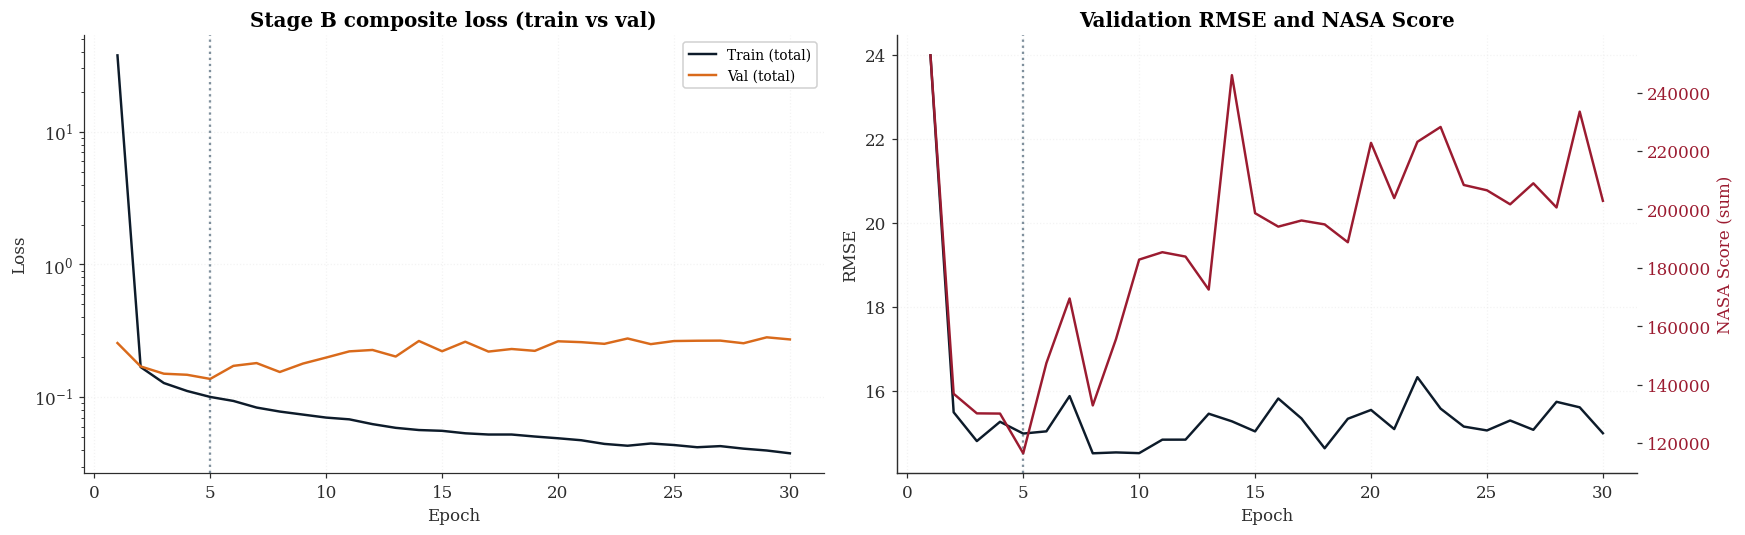

In [59]:
# ============================================================================
# Cell 12 — Visual: Loss Curves and Metrics over Epochs
# ============================================================================
epochs   = [h["epoch"] for h in history]
tr_total = [h["train"]["loss"] for h in history]
va_total = [h["val"]["loss"] for h in history]
va_rmse  = [h["val"]["rmse"] for h in history]
va_nasa  = [h["val"]["nasa_score"] for h in history]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(epochs, tr_total, color=FC_DARK_BLUE, linewidth=1.6, label="Train (total)")
axes[0].plot(epochs, va_total, color=FC_ORANGE,    linewidth=1.6, label="Val (total)")
axes[0].axvline(best_epoch, color=FC_STEEL, linestyle=":", alpha=0.7)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_yscale("log")
axes[0].set_title("Stage B composite loss (train vs val)")
axes[0].legend(); axes[0].grid(linestyle=":", alpha=0.5)

axes[1].plot(epochs, va_rmse, color=FC_DARK_BLUE, linewidth=1.6, label="Val RMSE (cycles)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("RMSE")
axes[1].grid(linestyle=":", alpha=0.5)
ax2 = axes[1].twinx()
ax2.plot(epochs, va_nasa, color=FC_DEEP_RED, linewidth=1.6, label="Val NASA")
ax2.set_ylabel("NASA Score (sum)", color=FC_DEEP_RED)
ax2.tick_params(axis="y", labelcolor=FC_DEEP_RED)
axes[1].axvline(best_epoch, color=FC_STEEL, linestyle=":", alpha=0.7)
axes[1].set_title("Validation RMSE and NASA Score")
plt.tight_layout()
plt.savefig(V2_OUT / "phase_v2_0_loss_curves.png", dpi=300, bbox_inches="tight")
plt.show()

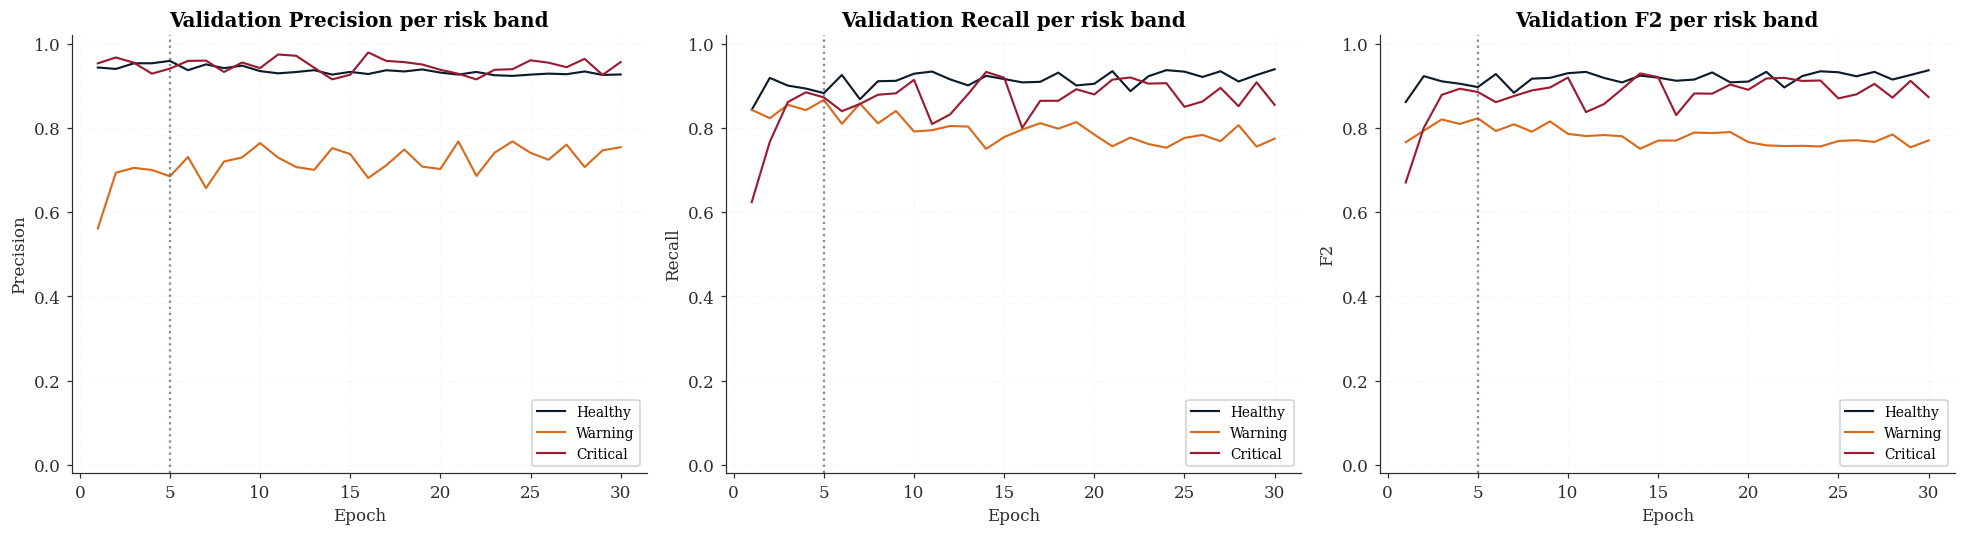

In [60]:
# ============================================================================
# Cell 13 — Visual: Per-Class Precision / Recall / F2 over Epochs
# ============================================================================
precs = np.array([h["val"]["precision"] for h in history])
recs  = np.array([h["val"]["recall"]    for h in history])
f2s   = np.array([h["val"]["f2"]        for h in history])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
band_names = ["Healthy", "Warning", "Critical"]
colors = [FC_DARK_BLUE, FC_ORANGE, FC_DEEP_RED]
for ax, metric, mname in [(axes[0], precs, "Precision"),
                          (axes[1], recs,  "Recall"),
                          (axes[2], f2s,   "F2")]:
    for c in range(3):
        ax.plot(epochs, metric[:, c], color=colors[c], linewidth=1.4, label=band_names[c])
    ax.axvline(best_epoch, color=FC_STEEL, linestyle=":", alpha=0.7)
    ax.set_xlabel("Epoch"); ax.set_ylabel(mname)
    ax.set_title(f"Validation {mname} per risk band")
    ax.set_ylim(-0.02, 1.02)
    ax.grid(linestyle=":", alpha=0.5)
    ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(V2_OUT / "phase_v2_0_critical_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

---

## Ph-v2.0 Gate

In [61]:
# ============================================================================
# Cell 14 — Ph-v2.0 Gate
# ----------------------------------------------------------------------------
# v2 deviation 2026-05-09 (see v2CLAUDE.md §7 entry v2.D1): the original gate
# required Stage B Internal Val NASA ≤ Stage A best (100,488). That criterion
# is structurally incompatible with the §4 mitigations — Stage B deliberately
# down-weights NASA loss (×1/50) and removes the stratified sampler that
# Stage A used to beat NASA on Internal Val. The lesson v1.P14 failure (Δ
# Critical recall = −0.51) is a NASA TEST SET generalisation gap, not an
# Internal Val phenomenon, so the Ph-v2.0 gate cannot measure the v2 thesis
# at all (Iron Wall §6 locks NASA test until Ph-v2.3). The gate is therefore
# a *training-sanity* gate: it confirms Stage B trained without pathology and
# left the model in a state where Ph-v2.1 conformal calibration can produce
# meaningful intervals.
# ============================================================================
print("="*78); print("  Ph-v2.0 GATE — Stage B Training Sanity"); print("="*78)
checks = []
checks.append(("No NaN/Inf gradients during training",
               not nan_grad_seen, "no NaN/Inf" if not nan_grad_seen else "NaN/Inf"))
checks.append(("At least 5 epochs completed",
               len(history) >= 5, f"{len(history)} epochs"))
window = max(1, len(history)//10)
first_avg = float(np.mean([h["train"]["loss"] for h in history[:window]]))
last_avg  = float(np.mean([h["train"]["loss"] for h in history[-window:]]))
checks.append(("Training loss descended (last 10% < 90% of first 10%)",
               last_avg < first_avg * 0.9, f"first={first_avg:.4f} last={last_avg:.4f}"))
init_val = history[0]["val"]["nasa_score"]
checks.append(("Best val NASA improved on initial",
               best_val_nasa < init_val, f"init={init_val:.0f} best={best_val_nasa:.0f}"))

# Sanity envelope (replaces the original "≤ Stage A" check). The 1.5× ceiling
# catches catastrophic overfit / divergence — anything tighter penalises Stage
# B for the §4 trade-offs that v2 was explicitly designed to take.
v1_a_best_val_nasa = 100488     # v1 Stage A v1.3 best (Internal Val NASA)
nasa_ceiling = int(1.5 * v1_a_best_val_nasa)   # 150,732
checks.append((f"Best val NASA within 1.5x Stage A envelope (≤ {nasa_ceiling:,})",
               best_val_nasa <= nasa_ceiling,
               f"stage_b={best_val_nasa:.0f} ceiling={nasa_ceiling:,}"))

# RUL accuracy sanity. The v0 XGBoost NASA-test RMSE was 14.85; we require
# Stage B's Internal Val RMSE within 1.5× of that bar so Ph-v2.1 conformal
# intervals are bounded enough to be operationally useful.
xgb_v0_rmse = 14.85
rmse_ceiling = 1.5 * xgb_v0_rmse                # 22.275
best_epoch_record = next(h for h in history if h["epoch"] == best_epoch)
best_val_rmse = float(best_epoch_record["val"]["rmse"])
checks.append((f"Best-epoch val RMSE ≤ {rmse_ceiling:.2f} (1.5x v0 XGBoost)",
               best_val_rmse <= rmse_ceiling,
               f"stage_b_rmse={best_val_rmse:.3f}"))

# Critical-band sanity. The thesis (§1) is that Stage B preserves Critical
# recall. We require ≥ 0.80 at the best epoch — Ph-v2.1 needs the classifier
# probabilities to be non-degenerate before temperature scaling can help.
best_val_critR = float(best_epoch_record["val"]["recall"][2])
checks.append(("Best-epoch Critical-band recall ≥ 0.80",
               best_val_critR >= 0.80, f"R_C={best_val_critR:.3f}"))
max_critical_recall = float(max(h["val"]["recall"][2] for h in history))
checks.append(("Critical-class recall reached > 0.50 mid-training",
               max_critical_recall > 0.50, f"max R_C = {max_critical_recall:.3f}"))

final_loss = history[-1]["val"]["loss"]
checks.append(("Final val loss finite",
               np.isfinite(final_loss), f"{final_loss:.4f}"))
for fn in ("phase_v2_0_pinet_stage_b_best.pt",
           "phase_v2_0_pinet_stage_b_last.pt",
           "phase_v2_0_training_history.json",
           "phase_v2_0_loss_curves.png",
           "phase_v2_0_critical_metrics.png"):
    checks.append((f"Persisted: {fn}", (V2_OUT / fn).exists(), "OK"))

# Round-trip best.
try:
    sd = torch.load(V2_OUT / "phase_v2_0_pinet_stage_b_best.pt",
                     map_location="cpu", weights_only=True)
    test_model = PiNet().to("cpu")
    test_model.load_state_dict(sd)
    rt = True
except Exception:
    rt = False
checks.append(("Best state-dict round-trips into a fresh PiNet", rt, "OK"))

for desc, ok, detail in checks:
    flag = "PASS" if ok else "FAIL"
    print(f"  [{flag}] {desc:<60s} {detail}")
n_pass = sum(1 for _,o,_ in checks if o)
print(f"\n  Ph-v2.0 GATE: {n_pass}/{len(checks)} PASS")
if not all(o for _,o,_ in checks):
    fails = [d for d, o, _ in checks if not o]
    print(f"\n  FAILING checks ({len(fails)}):")
    for f in fails:
        print(f"    - {f}")
assert all(o for _,o,_ in checks), "Ph-v2.0 GATE FAILED"
print("  Ph-v2.0 — proceed to Ph-v2.1 (conformal calibration)")

  Ph-v2.0 GATE — Stage B Training Sanity
  [PASS] No NaN/Inf gradients during training                         no NaN/Inf
  [PASS] At least 5 epochs completed                                  30 epochs
  [PASS] Training loss descended (last 10% < 90% of first 10%)        first=12.6256 last=0.0395
  [PASS] Best val NASA improved on initial                            init=252742 best=116559
  [PASS] Best val NASA within 1.5x Stage A envelope (≤ 150,732)       stage_b=116559 ceiling=150,732
  [PASS] Best-epoch val RMSE ≤ 22.27 (1.5x v0 XGBoost)                stage_b_rmse=14.994
  [PASS] Best-epoch Critical-band recall ≥ 0.80                       R_C=0.873
  [PASS] Critical-class recall reached > 0.50 mid-training            max R_C = 0.933
  [PASS] Final val loss finite                                        0.2726
  [PASS] Persisted: phase_v2_0_pinet_stage_b_best.pt                  OK
  [PASS] Persisted: phase_v2_0_pinet_stage_b_last.pt                  OK
  [PASS] Persisted: phase_v2

---

## Summary

### Ph-v2.0 outputs (under `v2/outputs/`)
- `phase_v2_0_pinet_stage_b_best.pt` — input to Ph-v2.1
- `phase_v2_0_pinet_stage_b_last.pt` — for resume
- `phase_v2_0_training_history.json`
- `phase_v2_0_loss_curves.png`, `phase_v2_0_critical_metrics.png`

### Next notebook
`02_Conformal_Calibration.ipynb` — split-conformal RUL intervals at α ∈ {0.05, 0.10, 0.20}.